# Prediction - Inpatient Bed Utilization Above State Threshold

## Import Dependencies

In [ ]:
from datetime import datetime
import lightgbm as lgb
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import shap

/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Parameters

In [2]:
ANALYSIS_START = datetime(2022, 1, 1)
ANALYSIS_END = datetime(2024, 4, 27)
FEATURE_WINDOWS = [1, 2, 3, 7, 14, 21, 28] # units in days
STATE_PERCENTILE = 0.80 # percentile threshold for `inpatient_beds_utilization`
DAYS_AHEAD = 7 # number of days to predict ahead
FOLDS= 5
MISSINGNESS_PROP = 0.8
THRESHOLD_YEAR = 2021

## Load Data

In [3]:
df = pd.read_csv('data/covid_features_all_states_20200101_20251231.csv')

df.head()

,date,state,fb-survey_smoothed_wwearing_mask_7d,fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept,google-symptoms_sum_anosmia_ageusia_smoothed_search,fb-survey_smoothed_wcli,fb-survey_smoothed_whh_cmnty_cli,doctor-visits_smoothed_adj_cli,jhu-csse_confirmed_incidence_num,hhs_confirmed_admissions_covid_1d_prop_7dav,...,inpatient_beds_utilization,percent_of_inpatients_with_covid,inpatient_bed_covid_utilization,adult_icu_bed_covid_utilization,adult_icu_bed_utilization,cases_roll_7,day_of_year,day_of_week,month_of_year,quarter_of_year
0,2020-01-01,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,1
1,2020-01-02,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,3,1,1
2,2020-01-03,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1,1
3,2020-01-04,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4,5,1,1
4,2020-01-05,AK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,6,1,1


## Data Preprocessing and Feature Engineering

In [4]:
# convert to datetime
df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d')

# sor time series
df = df.sort_values(by=['state', 'date'])

# Need to use `pd.concat` to prevent fragmented dataframe
years = df['date'].dt.year.to_frame()
years.columns = ['year']
months = df['date'].dt.month.to_frame()
months.columns = ['month']
days = df['date'].dt.day_of_week.to_frame()
days.columns = ['dayofweek']
weeks = df['date'].dt.isocalendar().week.astype('int').to_frame()
weeks.columns = ['weekofyear']
df = pd.concat([df, years, months, days, weeks], axis=1)

df = df.set_index('date', drop=False)

df['date'].head()

date
2020-01-01   2020-01-01
2020-01-02   2020-01-02
2020-01-03   2020-01-03
2020-01-04   2020-01-04
2020-01-05   2020-01-05
Name: date, dtype: datetime64[us]

In [5]:
# Use 2020 data to get obtain state-specific threshold for `inpatient_beds_utilization`
means = df[df['date'].dt.year==THRESHOLD_YEAR].groupby('state').mean()

state_thresholds = df[df['date'].dt.year==THRESHOLD_YEAR][['inpatient_beds_utilization', 'state']].groupby('state').quantile(STATE_PERCENTILE)
state_thresholds.columns = ['state_thresholds']

df = pd.merge(left=df, right=state_thresholds, how = 'inner', left_on='state', right_on='state')

df[['inpatient_beds_utilization', 'state', 'state_thresholds']].head()

,inpatient_beds_utilization,state,state_thresholds
0,NaN,AK,0.722062
1,NaN,AK,0.722062
2,NaN,AK,0.722062
3,NaN,AK,0.722062
4,NaN,AK,0.722062


In [6]:
# Create Target Variable
df = df.copy()
df_grouped = df.groupby(['state'])['inpatient_beds_utilization'].shift(-1*DAYS_AHEAD)
df['target'] = (df_grouped > df['state_thresholds']).astype('int')

In [7]:
# Filter Data to Only Dates When `inpatient_beds_utilization` is measured
df = df[(df['date'] >= ANALYSIS_START) & (df['date'] <= ANALYSIS_END)].reset_index(drop=True)

<Axes: title={'center': 'Distribution at 80% Percentile'}, xlabel='target'>

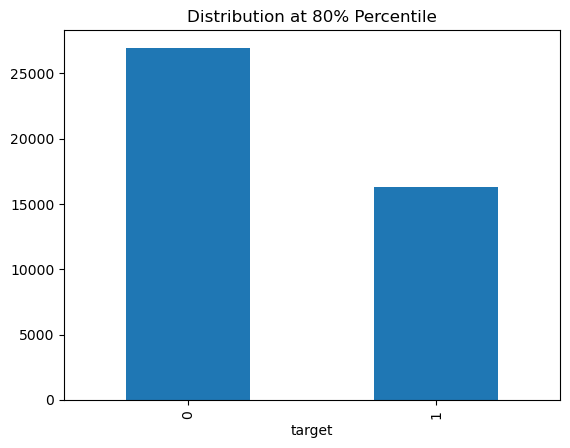

In [8]:
# Plot Target Variable
df['target'].value_counts().plot(kind='bar', title=f"Distribution at {int(100*STATE_PERCENTILE)}% Percentile")

Text(0.5, 1.0, 'Inpatient Capacity of VA Over Time')

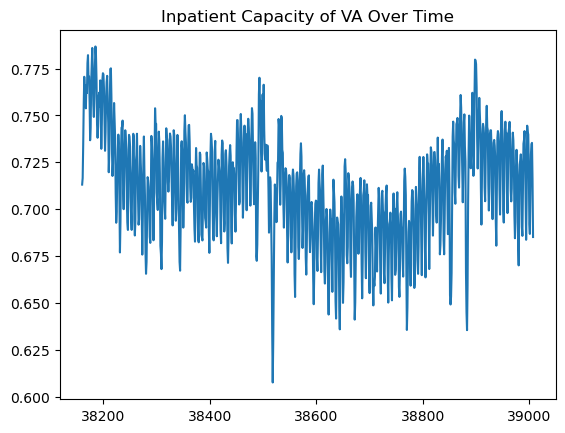

In [9]:
ex_state = 'VA' 
df_ex = df[df['state']==ex_state]
plt.plot(df_ex['inpatient_beds_utilization'])
plt.title(f"Inpatient Capacity of {ex_state} Over Time")

In [10]:
# Investigate Missing Values

missingness_pcts = df.isna().sum() / df.shape[0] 
features_to_drop = missingness_pcts[missingness_pcts > MISSINGNESS_PROP].index.to_list()

features_to_drop

['google-symptoms_sum_anosmia_ageusia_smoothed_search']

In [11]:
# Drop Features with High Missingness

df = df.drop(columns=features_to_drop)

# Remaining Features
df.columns.sort_values().to_list()

['adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_denominator',
 'adult_icu_bed_utilization_numerator',
 'cases_roll_7',
 'chng_7dav_inpatient_covid',
 'chng_smoothed_adj_outpatient_covid',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_today_yes',
 'date',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'deaths_covid',
 'deaths_covid_coverage',
 'doctor-visits_smoothed_adj_cli',
 'fb-survey_smoothed_wcli',
 'fb-survey_smoothed_wcovid_vaccinated_appointment_or_accept',
 'fb-survey_smoothed_whh_cmnty_cli',
 'fb-survey

In [12]:
cols = [col for col in df.columns if col != 'state']

df[cols] = df[cols].fillna(df[cols].mean())

In [13]:
df.isna().sum().sum()

np.int64(0)

In [14]:
# IMPORTANT: Can't Use K-fold because it risks leaking future data into training and inference

X = df.drop(columns=['target'])

y = df['target']

tscv = TimeSeriesSplit(n_splits=FOLDS)

## Baseline Model

In [15]:
# Need to prove that our ML models beat basic heuristics

from sklearn.metrics import f1_score
import numpy as np

unique_dates = X.index.unique()

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]

    preds = (X_test['inpatient_beds_utilization'] > X_test['state_thresholds']).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)
std = np.std(scores)

print(f"Baseline Results: {results:.3f} with {std:.3f} std.")

Baseline Results: 0.829 with 0.013 std.


## ARIMA

In [16]:
import statsmodels

# Confirm data is stationary before running ARIMA model

statsmodels.tsa.stattools.adfuller(df_ex['inpatient_beds_utilization'])

(np.float64(-3.3814378287104074),
 np.float64(0.0116081670709184),
 21,
 826,
 {'1%': np.float64(-3.4382915719823934),
  '5%': np.float64(-2.8650454292904577),
  '10%': np.float64(-2.568636586835826)},
 np.float64(-5341.82866652402))

In [17]:
scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    for state in X_train['state'].unique():
        X_train_t = X_train[X_train['state']==state]['inpatient_beds_utilization']
        if len(X_train_t) < 30:
            continue
        mod = ARIMA(endog=X_train_t, order = (5,1,1))
        res = mod.fit()
        X_test_t = X_test[X_test['state']==state]
        y_test_t = y_test[X_test['state']==state]
        if len(y_test_t) < 30:
            continue
        forecast = res.forecast(steps=len(y_test_t))
        preds = (forecast > X_test_t['state_thresholds']).astype('int')

        scores.append(f1_score(y_test_t, preds))

results = np.mean(scores)

print(f"ARIMA Results: {results:.3f}")

/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

ARIMA Results: 0.584


/Users/johnwhendricks/miniforge3/envs/ds5003/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Boosting

In [85]:
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=['target'])

y = df['target']

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] =(
    (X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist', 
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby('state')[f].shift(w)
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    X_train = X_train.drop(columns=['state'])

    X_test = X_test.drop(columns=['state'])

    feats = ['dist', 'dist_14_day_lag', 'dist_21_day_lag', 'day_of_year',
        'dist_7_day_lag', 'dist_28_day_lag', 'dist_28_day_rolling',
        'day_of_week', 'dist_2_day_rolling',
        'hhs_confirmed_admissions_covid_1d_prop_7dav', 'dist_1_day_lag',
        'dist_21_day_rolling', 'dist_7_day_rolling',
        'jhu-csse_deaths_7dav_incidence_prop', 'weekofyear',
        'chng_smoothed_adj_outpatient_covid']
    
    X_train = X_train[feats]
    X_test = X_test[feats]

    sample_weights = (y_train==0).sum() / (y_train==1).sum()

    mod = xgb.XGBClassifier(
        n_estimators = 200, 
        max_depth = 6, 
        learning_rate=0.07, 
        scale_pos_weight = sample_weights,
        min_child_weight = 8    
    )

    mod.fit(X_train, y_train)

    probs = mod.predict_proba(X_test)[:, 1]

    preds = (probs > 0.5).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)
stds = np.std(scores)

print(f"XGBClassifier Results: {results:.3f} with {stds:.3f} std.")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/2697427921.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/2697427921.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] =(
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/2697427921.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

XGBClassifier Results: 0.866 with 0.010 std.


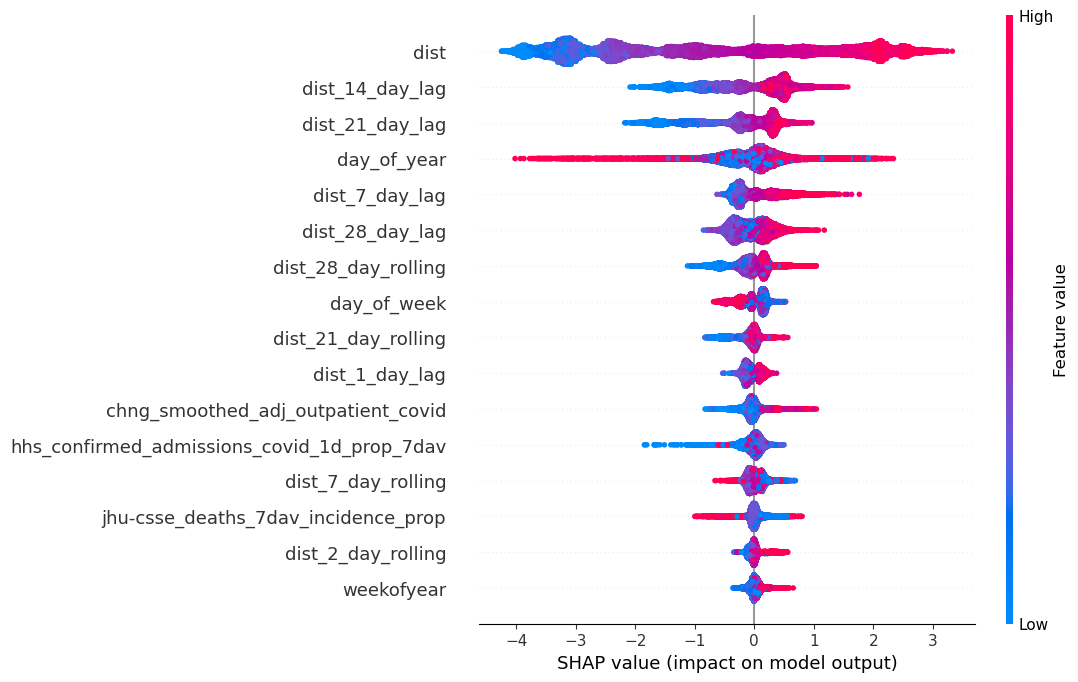

In [89]:
explainer = shap.TreeExplainer(mod)
explanation = explainer(X_train) 

shap.plots.beeswarm(explanation, max_display=21)

In [20]:
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=['target'])

y = df['target']

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] =(
    (X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist', 
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby(['state'], as_index=False).shift(w)[f]
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    X_train = X_train.drop(columns=['state'])

    X_test = X_test.drop(columns=['state'])

    # feats = [
    #     'dist', 'dist_21_day_lag', 'dist_14_day_lag', 
    #     'dist_28_day_lag', 'dist_7_day_lag', 'day_of_year', 
    #     'dist_28_day_rolling', 'dist_1_day_lag', 'jhu-csse_deaths_7dav_incidence_prop',
    #     'day_of_week', 'weekofyear', 'dist_21_day_rolling'
    # ]

    feats = [
    'dist', 'dist_14_day_lag', 'dist_21_day_lag', 'dist_7_day_lag',
       'dist_28_day_lag', 'day_of_year', 'dist_28_day_rolling',
       'dist_1_day_lag', 'day_of_week', 'dist_21_day_rolling', 'weekofyear',
       'chng_smoothed_adj_outpatient_covid',
       'hhs_confirmed_admissions_covid_1d_prop_7dav']
    
    X_train = X_train[feats]
    X_test = X_test[feats]

    sample_weights = (y_train==0).sum() / (y_train==1).sum()

    mod = lgb.LGBMClassifier(
        n_estimators = 200, sample_weights = 'balanced'
    )

    mod.fit(X_train, y_train)

    probs = mod.predict_proba(X_test)[:, 1]

    preds = (probs > 0.5).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)
stds = np.std(scores)

print(f"LGBMClassifier Results: {results:.3f} with {stds:.3f} std.")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/4276008391.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/4276008391.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] =(
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/4276008391.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

[LightGBM] [Warning] Unknown parameter: sample_weights
[LightGBM] [Warning] Unknown parameter: sample_weights
[LightGBM] [Info] Number of positive: 2720, number of negative: 4488
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2865
[LightGBM] [Info] Number of data points in the train set: 7208, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.377358 -> initscore=-0.500775
[LightGBM] [Info] Start training from score -0.500775
[LightGBM] [Warning] Unknown parameter: sample_weights
[LightGBM] [Warning] Unknown parameter: sample_weights
[LightGBM] [Warning] Unknown parameter: sample_weights
[LightGBM] [Info] Number of positive: 5348, number of negative: 9068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[Li

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=['target'])

y = df['target']

X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']

X['streak'] =(
    (X['dist'].shift(1) > 0) & (X['dist'].shift(2) > 0)
).astype('int')

FEATURES_TO_LAG = [
    'inpatient_beds_utilization', 'dist', 
]

enc = OneHotEncoder(sparse_output=False)
enc.fit(X[['state']])
encoded_states = enc.transform(X[['state']])
state_cols = list(enc.get_feature_names_out(['state']))
df_states = pd.DataFrame(encoded_states, columns = state_cols)

X = pd.concat([X, df_states], axis=1).drop(columns=['date'])

for w in FEATURE_WINDOWS:
    for f in FEATURES_TO_LAG:
        X[f"{f}_{w}_day_lag"] = X.groupby(['state'], as_index=False).shift(w)[f]
        X[f"{f}_{w}_day_rolling"] = X.groupby(['state'], as_index=False).rolling(w).mean()[f]

scores = []
for train_index, test_index in tscv.split(unique_dates):
    dates_train = unique_dates[train_index]
    dates_test = unique_dates[test_index]

    X_train = X[X.index.isin(dates_train)]
    y_train = y[y.index.isin(dates_train)]
    X_test = X[X.index.isin(dates_test)]
    y_test = y[y.index.isin(dates_test)]


    X_train = X_train.drop(columns=['state'])

    X_test = X_test.drop(columns=['state'])

    # feats = [
    #     'dist', 'dist_21_day_lag', 'dist_14_day_lag', 
    #     'dist_28_day_lag', 'dist_7_day_lag', 'day_of_year', 
    #     'dist_28_day_rolling', 'dist_1_day_lag', 'jhu-csse_deaths_7dav_incidence_prop',
    #     'day_of_week', 'weekofyear', 'dist_21_day_rolling'
    # ]

    feats = [
    'dist', 'dist_14_day_lag', 'dist_21_day_lag', 'dist_7_day_lag',
       'dist_28_day_lag', 'day_of_year', 'dist_28_day_rolling',
       'dist_1_day_lag', 'day_of_week', 'dist_21_day_rolling', 'weekofyear',
       'chng_smoothed_adj_outpatient_covid',
       'hhs_confirmed_admissions_covid_1d_prop_7dav']
    
    X_train = X_train[feats]
    X_test = X_test[feats]


    mod = HistGradientBoostingClassifier()

    mod.fit(X_train, y_train)

    probs = mod.predict_proba(X_test)[:, 1]

    preds = (probs > 0.5).astype('int')

    scores.append(f1_score(y_test, preds))

results = np.mean(scores)
stds = np.std(scores)

print(f"HistGradientBoostingClassifier Results: {results:.3f} with {stds:.3f} std.")

/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/97798241.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['dist'] = X['inpatient_beds_utilization'] - X['state_thresholds']
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/97798241.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['streak'] =(
/var/folders/sx/dymxkj2j1636xvkc7jyhyp840000gn/T/ipykernel_42020/97798241.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

HistGradientBoostingClassifier Results: 0.863 with 0.013 std.
